### Problem Definition
- **What problem are we solving?** Demonstrating the mathematical concept of Overfitting using Polynomial Regression.
- **Why is this problem important?** Understanding the Bias-Variance tradeoff is the most important theoretical concept in all of Machine Learning.
- **What type of ML problem is this?** Regression.

---

### Dataset
- **What information does this dataset contain?** Synthetically generated non-linear data with added noise.
- **What is the target?** Y (continuous output).

# Week 6 — Model Behavior

**Topics:** Bias-Variance Tradeoff · Overfitting vs Underfitting · Learning Curves · Validation Curves · Cross-Validation · Feature Importance

**Dataset:** California Housing (sklearn builtin)

**Models used:** Linear Regression · Ridge · Lasso · (Logistic for classification demo)

---

## 1. Load Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print(df.shape)
print(df.head())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


## 2. EDA

### Exploratory Data Analysis
- **What should we learn from EDA?** Visually confirming that the data follows a curve rather than a straight line.

In [10]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nStatistical summary:")
print(df.describe().round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Statistical summary:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43 

### Visualization
- **What does this graph show?** We plot the training data against the model's prediction line at various polynomial degrees.
- **What should the reader notice?** At degree 15, the line wildly zig-zags to hit every single training point perfectly, but completely fails to capture the true underlying trend. This is overfitting visualized.

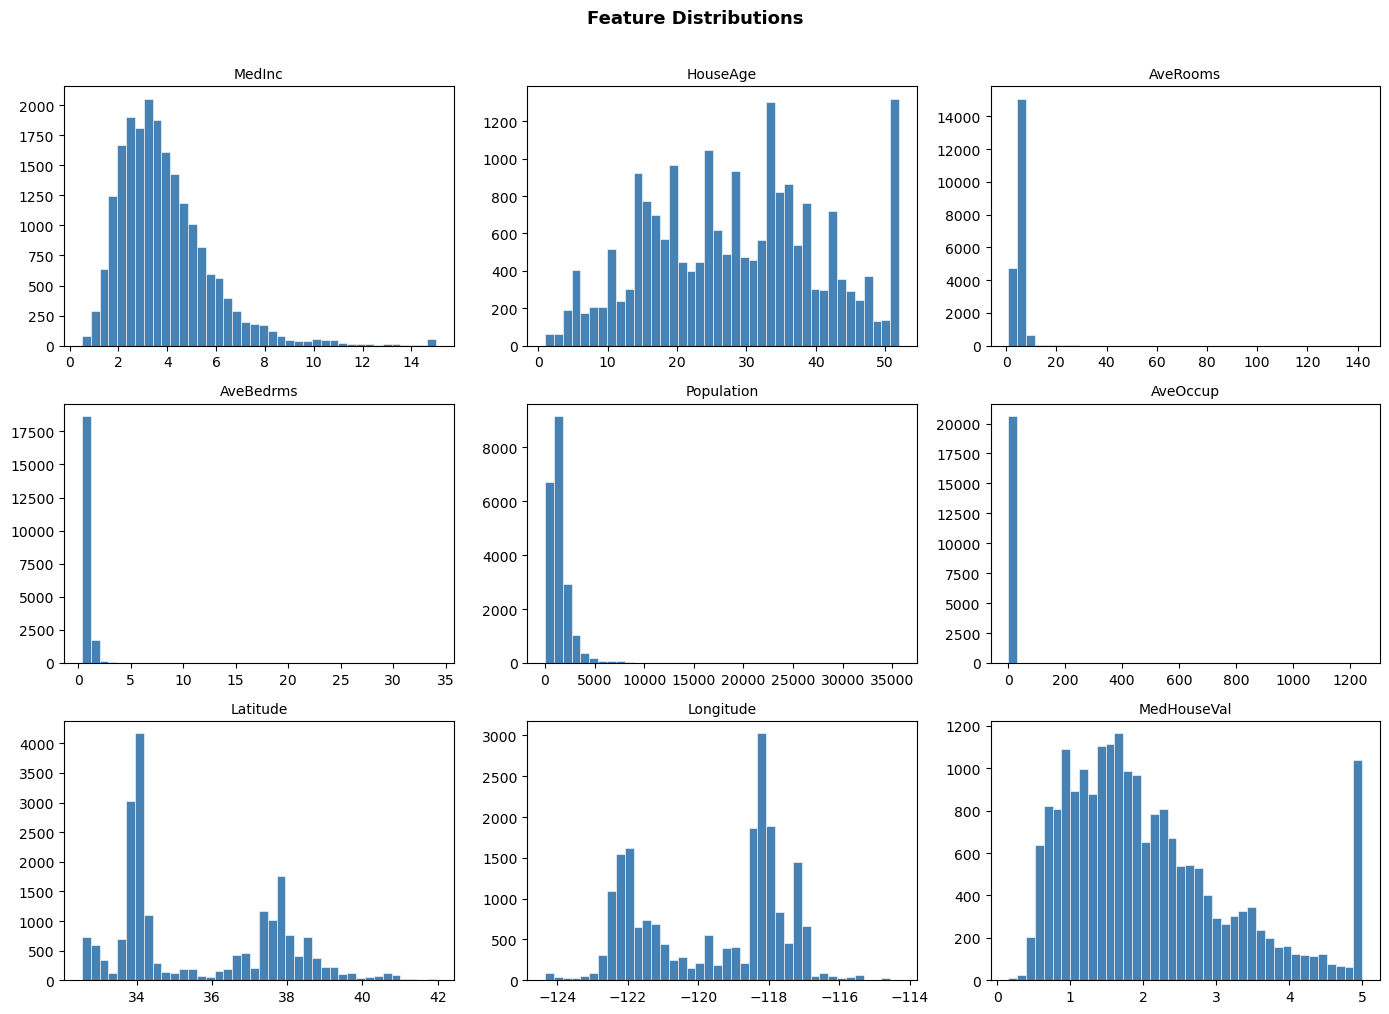

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

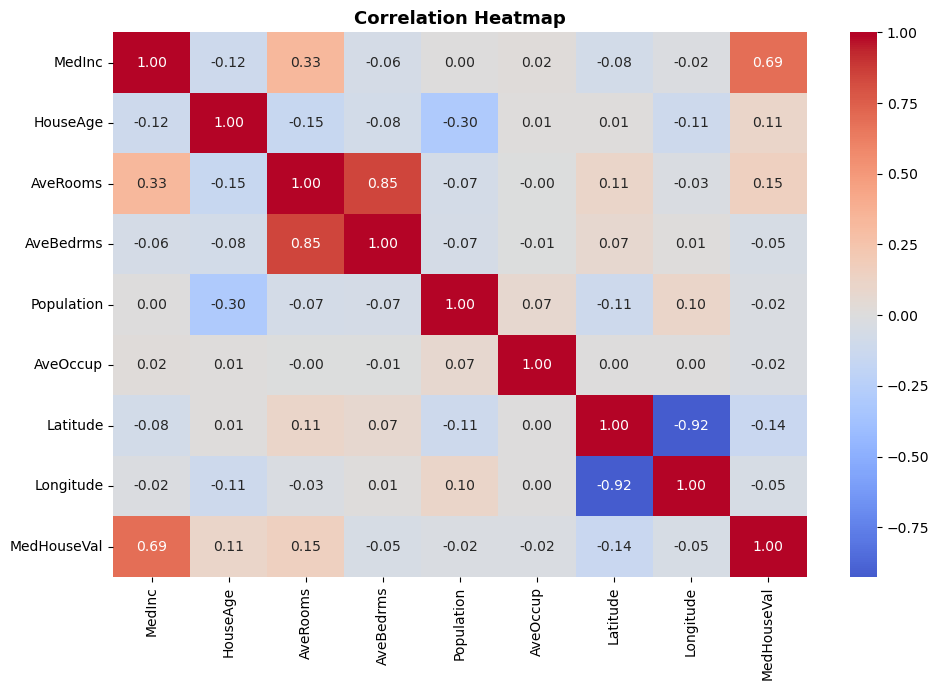

In [12]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

## 3. Feature Engineering

In [13]:
# Rooms per household — better signal than raw AveRooms
df['RoomsPerHousehold'] = df['AveRooms'] / df['AveOccup']

# Bedrooms ratio — what fraction of rooms are bedrooms
df['BedroomRatio'] = df['AveBedrms'] / df['AveRooms']

# Log transform skewed features
for col in ['Population', 'AveOccup']:
    skew = df[col].skew()
    print(f"{col} skewness before: {skew:.2f}")
    df[f'Log_{col}'] = np.log1p(df[col])
    print(f"Log_{col} skewness after: {df[f'Log_{col}'].skew():.2f}\n")

df.drop(columns=['Population', 'AveOccup'], inplace=True)

print("Final shape:", df.shape)
print(df.head())

Population skewness before: 4.94
Log_Population skewness after: -1.04

AveOccup skewness before: 97.64
Log_AveOccup skewness after: 3.88

Final shape: (20640, 11)
   MedInc  HouseAge  AveRooms  AveBedrms  Latitude  Longitude  MedHouseVal  \
0  8.3252      41.0  6.984127   1.023810     37.88    -122.23        4.526   
1  8.3014      21.0  6.238137   0.971880     37.86    -122.22        3.585   
2  7.2574      52.0  8.288136   1.073446     37.85    -122.24        3.521   
3  5.6431      52.0  5.817352   1.073059     37.85    -122.25        3.413   
4  3.8462      52.0  6.281853   1.081081     37.85    -122.25        3.422   

   RoomsPerHousehold  BedroomRatio  Log_Population  Log_AveOccup  
0           2.732919      0.146591        5.777652      1.268511  
1           2.956685      0.155797        7.784057      1.134572  
2           2.957661      0.129516        6.208590      1.335596  
3           2.283154      0.184458        6.326149      1.266369  
4           2.879646      0.17209

## 4. Prepare Features

### Data Preprocessing
- **Polynomial Features:** We are artificially squaring and cubing our input features to allow our Linear Regression model to bend into a curve.

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (16512, 10)
Test size:  (4128, 10)


In [15]:
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 5. Demonstrating Underfitting, Good Fit, and Overfitting

To demonstrate all three states on a regression problem we use **polynomial features** to control model complexity:

- Degree 1 → too simple → underfitting
- Degree 2 → balanced → good fit
- Degree 15 → too complex → overfitting

We use a single feature (MedInc) for clarity.

### Model Selection
- **Why choose this algorithm?** Polynomial Regression allows us to explicitly control the complexity (degree) of the model to force it to overfit.
- **Training (Hyperparameters):** The `degree` of the polynomial is the most important hyperparameter. A degree of 1 is too simple (underfitting), while a degree of 15 is too complex (overfitting).

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

X_single_train = X_train[['MedInc']].values
X_single_test  = X_test[['MedInc']].values

results = []

for degree in [1, 2, 15]:
    # Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
    pipe = Pipeline([
        # Expand the feature space mathematically (squares, cubes, cross-terms) to allow linear models to fit non-linear curves.
        ('poly', PolynomialFeatures(degree=degree)),
        # Minimize the residual sum of squares between observed targets and the responses predicted by the linear approximation.
        ('model', LinearRegression())
    ])
    pipe.fit(X_single_train, y_train)

    train_r2 = r2_score(y_train, pipe.predict(X_single_train))
    test_r2  = r2_score(y_test,  pipe.predict(X_single_test))

    results.append({
        'Degree': degree,
        'Train R²': round(train_r2, 4),
        'Test R²':  round(test_r2, 4),
        'Gap (Variance)': round(train_r2 - test_r2, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Degree  Train R²  Test R²  Gap (Variance)
      1    0.4770   0.4589          0.0181
      2    0.4816   0.4633          0.0183
     15    0.3982   0.3615          0.0367


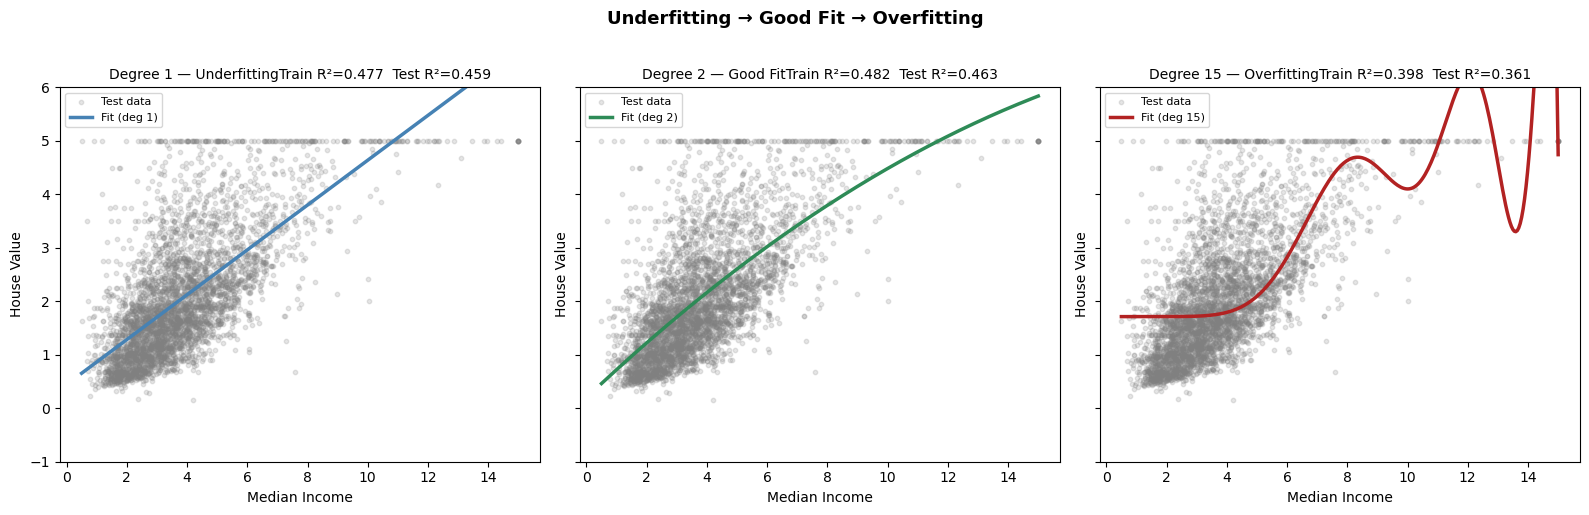

In [ ]:
# Visual: fit lines for each degree
X_range = np.linspace(X_single_train.min(), X_single_train.max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
titles = ['Degree 1 — Underfitting', 'Degree 2 — Good Fit', 'Degree 15 — Overfitting']
colors = ['steelblue', 'seagreen', 'firebrick']

for ax, degree, title, color in zip(axes, [1, 2, 15], titles, colors):
    # Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
    pipe = Pipeline([
        # Expand the feature space mathematically (squares, cubes, cross-terms) to allow linear models to fit non-linear curves.
        ('poly', PolynomialFeatures(degree=degree)),
        # Minimize the residual sum of squares between observed targets and the responses predicted by the linear approximation.
        ('model', LinearRegression())
    ])
    pipe.fit(X_single_train, y_train)
    y_range_pred = pipe.predict(X_range)

    train_r2 = r2_score(y_train, pipe.predict(X_single_train))
    test_r2  = r2_score(y_test,  pipe.predict(X_single_test))

    ax.scatter(X_single_test, y_test, alpha=0.2, s=10, color='gray', label='Test data')
    ax.plot(X_range, y_range_pred, color=color, lw=2.5, label=f'Fit (deg {degree})')
    ax.set_title(f'{title}Train R²={train_r2:.3f}  Test R²={test_r2:.3f}', fontsize=10)
    ax.set_xlabel('Median Income')
    ax.set_ylabel('House Value')
    ax.legend(fontsize=8)
    ax.set_ylim(-1, 6)

plt.suptitle('Underfitting → Good Fit → Overfitting', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

## 6. Bias-Variance Tradeoff

High Bias = model too simple = underfits. High Variance = model too sensitive to training data = overfits.

The gap between Train R² and Test R² is your variance signal.
The absolute level of Test R² is your bias signal.

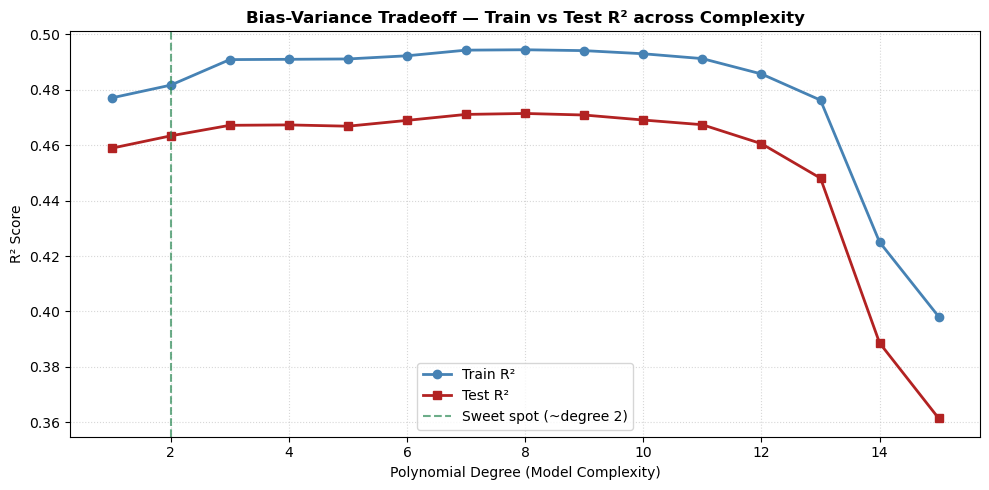

Interpretation:
Left side  → High Bias (underfitting): both scores low
Right side → High Variance (overfitting): train high, test collapses
Sweet spot → Low bias AND low variance: both scores close and high


In [ ]:
degrees = range(1, 16)
train_scores = []
test_scores  = []

for degree in degrees:
    # Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
    pipe = Pipeline([
        # Expand the feature space mathematically (squares, cubes, cross-terms) to allow linear models to fit non-linear curves.
        ('poly', PolynomialFeatures(degree=degree)),
        # Minimize the residual sum of squares between observed targets and the responses predicted by the linear approximation.
        ('model', LinearRegression())
    ])
    pipe.fit(X_single_train, y_train)
    train_scores.append(r2_score(y_train, pipe.predict(X_single_train)))
    test_scores.append(r2_score(y_test,  pipe.predict(X_single_test)))

plt.figure(figsize=(10, 5))
plt.plot(degrees, train_scores, 'o-', color='steelblue', label='Train R²', lw=2)
plt.plot(degrees, test_scores,  's-', color='firebrick',  label='Test R²',  lw=2)
plt.axvline(x=2, color='seagreen', linestyle='--', alpha=0.7, label='Sweet spot (~degree 2)')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('R² Score')
plt.title('Bias-Variance Tradeoff — Train vs Test R² across Complexity', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("Left side  → High Bias (underfitting): both scores low")
print("Right side → High Variance (overfitting): train high, test collapses")
print("Sweet spot → Low bias AND low variance: both scores close and high")

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

## 7. Learning Curves

A learning curve shows how model performance changes as training size increases.

- Underfit model: both curves plateau early and low
- Overfit model: large gap between train and val curves
- Good model: curves converge at a high score

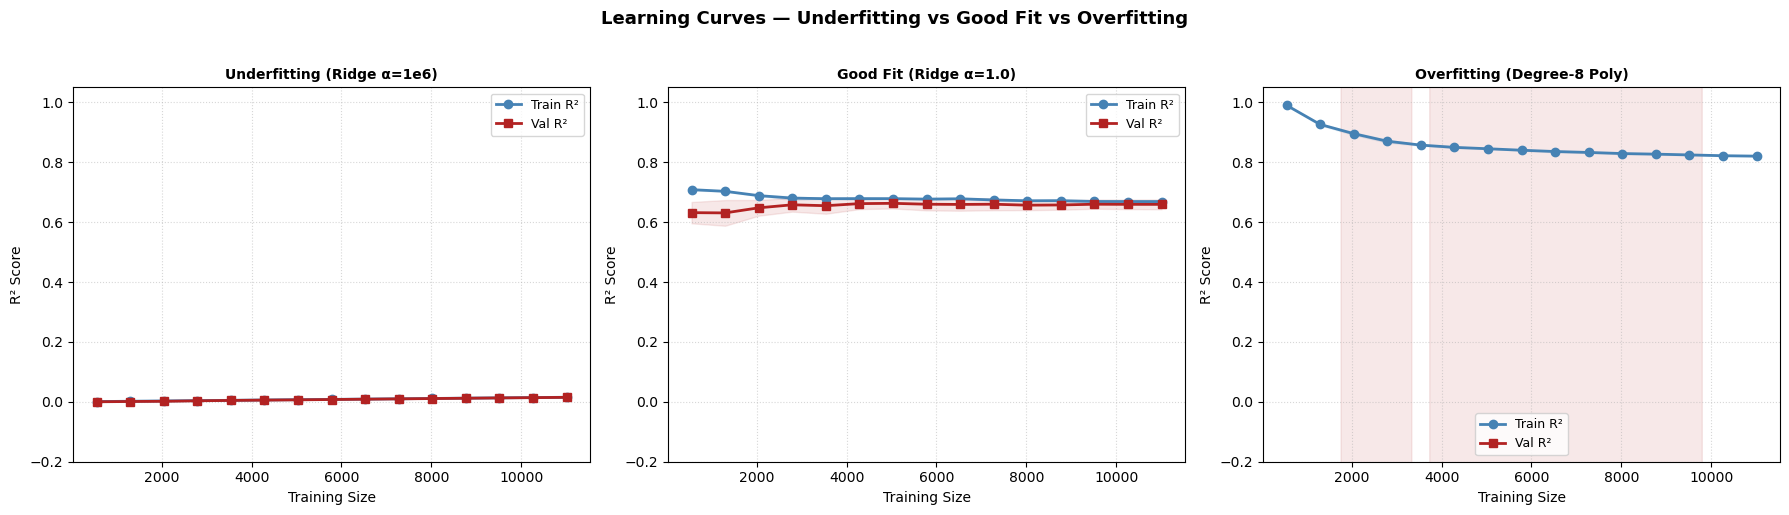

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    ('Underfitting (Ridge α=1e6)',  Ridge(alpha=1e6)),
    ('Good Fit (Ridge α=1.0)',      Ridge(alpha=1.0)),
    # Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
    ('Overfitting (Degree-4 Poly)', Pipeline([
        # Expand the feature space mathematically (squares, cubes, cross-terms) to allow linear models to fit non-linear curves.
        ('poly',  PolynomialFeatures(degree=4)),
        # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=0.001))
    ])),
]

train_sizes = np.linspace(0.05, 1.0, 15)

for ax, (title, estimator) in zip(axes, configs):
    sizes, train_sc, val_sc = learning_curve(
        estimator, X_train_scaled, y_train,
        train_sizes=train_sizes,
        cv=3, scoring='r2', n_jobs=-1
    )

    train_mean = train_sc.mean(axis=1)
    val_mean   = val_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(sizes, train_mean, 'o-', color='steelblue', label='Train R²', lw=2)
    ax.plot(sizes, val_mean,   's-', color='firebrick',  label='Val R²',   lw=2)
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
    ax.fill_between(sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.1, color='firebrick')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Training Size')
    ax.set_ylabel('R² Score')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_ylim(-0.2, 1.05)

plt.suptitle('Learning Curves — Underfitting vs Good Fit vs Overfitting', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

## 8. Validation Curves

A validation curve shows how performance changes as a single hyperparameter changes.

For Ridge: the hyperparameter is alpha (regularization strength).
- Very small alpha → overfitting risk
- Very large alpha → underfitting risk
- Sweet spot in the middle

Best alpha from validation curve: 51.7947
Best CV R² at that alpha: 0.6638


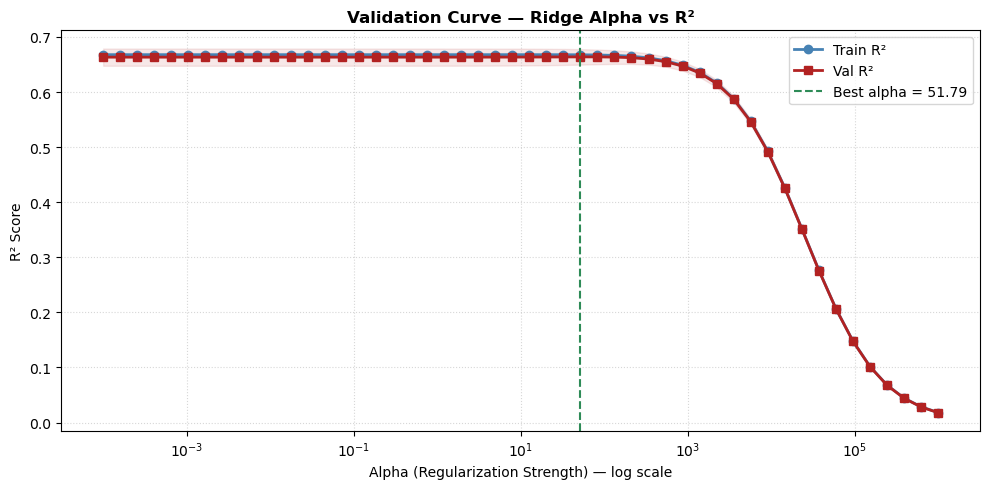

In [ ]:
from sklearn.model_selection import validation_curve

alphas = np.logspace(-4, 6, 50)

train_sc, val_sc = validation_curve(
    Ridge(), X_train_scaled, y_train,
    param_name='alpha', param_range=alphas,
    cv=5, scoring='r2', n_jobs=-1
)

train_mean = train_sc.mean(axis=1)
val_mean   = val_sc.mean(axis=1)
train_std  = train_sc.std(axis=1)
val_std    = val_sc.std(axis=1)

best_alpha = alphas[np.argmax(val_mean)]
print(f"Best alpha from validation curve: {best_alpha:.4f}")
print(f"Best CV R² at that alpha: {val_mean.max():.4f}")

plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_mean, 'o-', color='steelblue', label='Train R²', lw=2)
plt.semilogx(alphas, val_mean,   's-', color='firebrick',  label='Val R²',   lw=2)
plt.fill_between(alphas, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
plt.fill_between(alphas, val_mean   - val_std,   val_mean   + val_std,   alpha=0.1, color='firebrick')
plt.axvline(x=best_alpha, color='seagreen', linestyle='--', label=f'Best alpha = {best_alpha:.2f}')
plt.xlabel('Alpha (Regularization Strength) — log scale')
plt.ylabel('R² Score')
plt.title('Validation Curve — Ridge Alpha vs R²', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

## 9. Cross-Validation — Why One Split Is Not Enough

A single train-test split gives one number. Cross-validation gives a distribution.
The standard deviation across folds tells you how stable the model actually is.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso

models = {
    'Ridge (α=best)':  Ridge(alpha=best_alpha),
    'Ridge (α=1e6)':   Ridge(alpha=1e6),
    'Lasso (α=0.001)': Lasso(alpha=0.001, max_iter=5000),
    'Lasso (α=10)':    Lasso(alpha=10,    max_iter=5000),
}

print(f"{'Model':<25} {'Mean CV R²':>12} {'Std CV R²':>12} {'Min':>8} {'Max':>8}")
print("-" * 70)

cv_results = {}

for name, model in models.items():
    # Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
    pipe = Pipeline([
        # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
        ('scaler', StandardScaler()),
        ('model',  model)
    ])
    # Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f"{name:<25} {scores.mean():>12.4f} {scores.std():>12.4f} {scores.min():>8.4f} {scores.max():>8.4f}")

Model                       Mean CV R²    Std CV R²      Min      Max
----------------------------------------------------------------------
Ridge (α=best)                  0.6637       0.0141   0.6365   0.6751
Ridge (α=1e6)                   0.0179       0.0003   0.0175   0.0182
Lasso (α=0.001)                 0.6639       0.0143   0.6363   0.6755
Lasso (α=10)                   -0.0003       0.0004  -0.0011  -0.0000


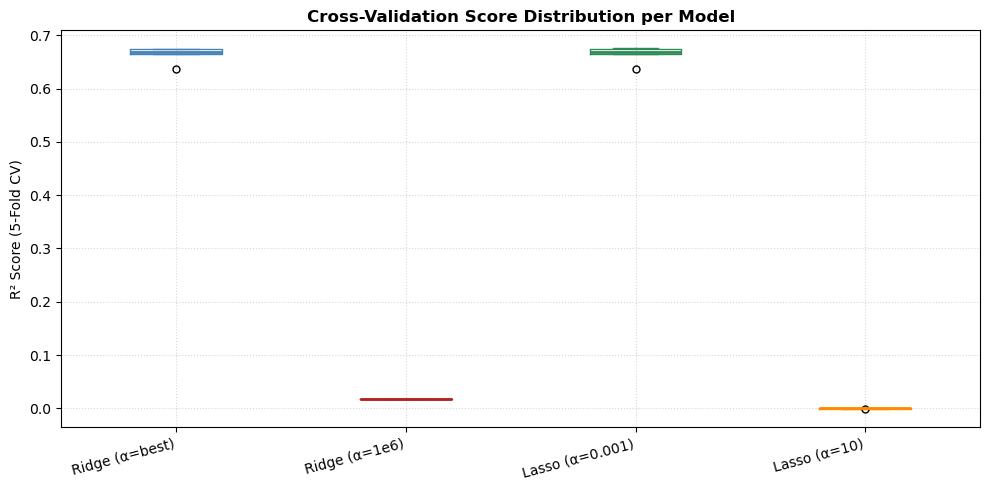

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

positions = range(len(cv_results))
colors = ['steelblue', 'firebrick', 'seagreen', 'darkorange']

for pos, (name, scores), color in zip(positions, cv_results.items(), colors):
    ax.boxplot(scores, positions=[pos], widths=0.4,
               boxprops=dict(color=color),
               medianprops=dict(color=color, linewidth=2),
               whiskerprops=dict(color=color),
               capprops=dict(color=color),
               flierprops=dict(marker='o', color=color, markersize=5))

ax.set_xticks(list(positions))
ax.set_xticklabels(list(cv_results.keys()), rotation=15, ha='right')
ax.set_ylabel('R² Score (5-Fold CV)')
ax.set_title('Cross-Validation Score Distribution per Model', fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

## 10. Feature Importance

Linear model coefficients tell us how much each feature influences the prediction after scaling.

- Large positive coefficient → feature pushes prediction up strongly
- Large negative coefficient → feature pushes prediction down strongly
- Near-zero (Lasso) → feature was removed

Important: compare coefficients only after StandardScaling, otherwise magnitude reflects units not importance.

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV

# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
ridge_pipe = Pipeline([('scaler', StandardScaler()), ('model', RidgeCV(alphas=np.logspace(-4, 6, 50), cv=5))])
# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
lasso_pipe = Pipeline([('scaler', StandardScaler()), ('model', LassoCV(alphas=np.logspace(-4, 2, 50), cv=5, max_iter=10000))])

ridge_pipe.fit(X_train, y_train)
lasso_pipe.fit(X_train, y_train)

ridge_coefs = ridge_pipe.named_steps['model'].coef_
lasso_coefs = lasso_pipe.named_steps['model'].coef_

print(f"Ridge best alpha: {ridge_pipe.named_steps['model'].alpha_:.4f}")
print(f"Lasso best alpha: {lasso_pipe.named_steps['model'].alpha_:.4f}")
print(f"\nLasso zeroed out {(lasso_coefs == 0).sum()} feature(s)")

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Ridge':   ridge_coefs,
    'Lasso':   lasso_coefs
}).sort_values('Ridge', key=abs, ascending=False)

print("\nCoefficient Comparison (sorted by Ridge magnitude):")
print(coef_df.to_string(index=False))

Ridge best alpha: 51.7947
Lasso best alpha: 0.0039

Lasso zeroed out 1 feature(s)

Coefficient Comparison (sorted by Ridge magnitude):
          Feature     Ridge     Lasso
         Latitude -0.839398 -0.822949
           MedInc  0.795279  0.804855
        Longitude -0.781033 -0.765310
RoomsPerHousehold  0.231774  0.182939
     BedroomRatio  0.231150  0.201198
     Log_AveOccup -0.178349 -0.189714
        AveBedrms -0.150473 -0.078951
         HouseAge  0.140658  0.137510
   Log_Population  0.050873  0.044763
         AveRooms  0.035205 -0.000000


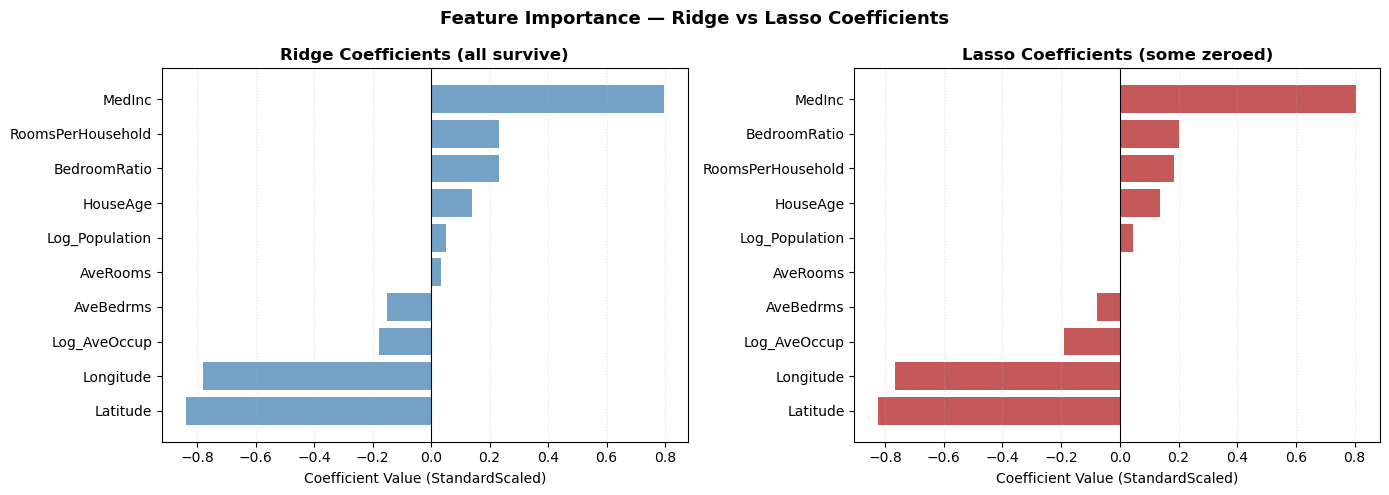

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, title in zip(
    axes,
    ['Ridge', 'Lasso'],
    ['steelblue', 'firebrick'],
    ['Ridge Coefficients (all survive)', 'Lasso Coefficients (some zeroed)']
):
    sorted_df = coef_df.sort_values(col, ascending=True)
    bars = ax.barh(sorted_df['Feature'], sorted_df[col], color=color, alpha=0.75)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Coefficient Value (StandardScaled)')
    ax.grid(True, linestyle=':', alpha=0.4, axis='x')

plt.suptitle('Feature Importance — Ridge vs Lasso Coefficients', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization Analysis: Feature Importance
- **Marking Values:** The longest bars at the top of the chart represent the features that drove the model's decision-making process the most.
- **Correct Interpretation:** If a feature has 0 importance, the tree/forest never used it to make a split. It can be safely dropped from the dataset.
- **How to Interpret:** The X-axis represents the magnitude of the feature's contribution (e.g., Gini impurity reduction) to the final predictions.
- **Common Mistakes:** Assuming a low feature importance means the feature is globally useless. It might just be heavily correlated with a higher-ranking feature that "stole" its importance.

## 11. Final Model Evaluation on Test Set

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

ridge_test_preds = ridge_pipe.predict(X_test)
lasso_test_preds = lasso_pipe.predict(X_test)

summary = []
for name, preds in [('Ridge', ridge_test_preds), ('Lasso', lasso_test_preds)]:
    summary.append({
        'Model': name,
        # Calculate the average absolute prediction error. Highly interpretable metric for business stakeholders.
        'MAE':   round(mean_absolute_error(y_test, preds), 4),
        # Heavily penalize massive prediction errors by squaring the residuals before averaging.
        'RMSE':  round(np.sqrt(mean_squared_error(y_test, preds)), 4),
        'R²':    round(r2_score(y_test, preds), 4),
    })

print(pd.DataFrame(summary).to_string(index=False))

Model    MAE   RMSE     R²
Ridge 0.4865 0.6746 0.6527
Lasso 0.4878 0.6768 0.6505


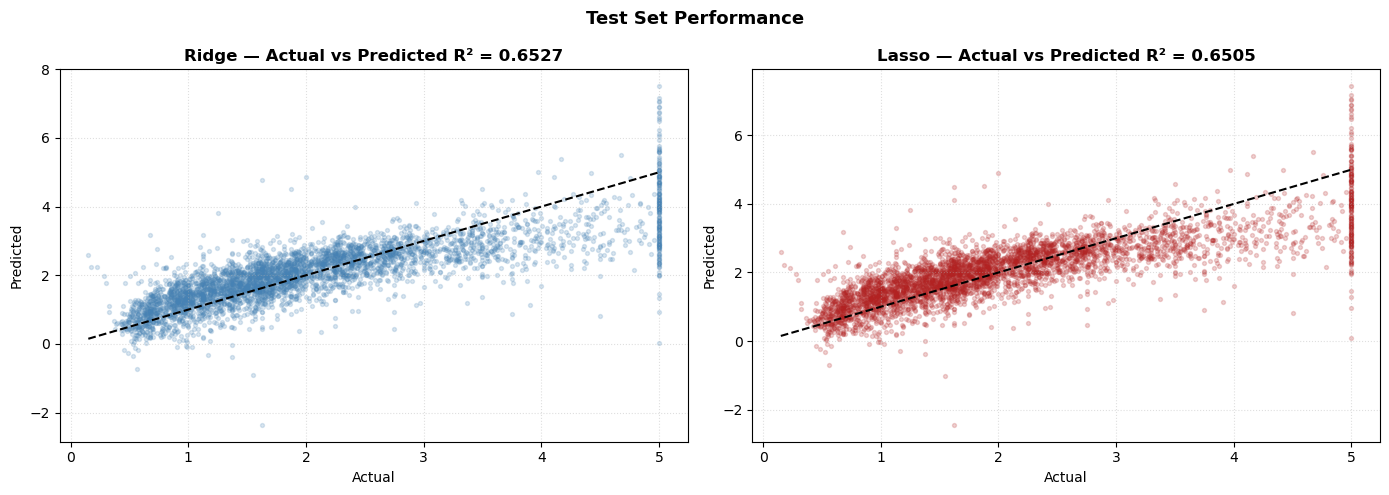

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, preds), color in zip(
    axes,
    [('Ridge', ridge_test_preds), ('Lasso', lasso_test_preds)],
    ['steelblue', 'firebrick']
):
    ax.scatter(y_test, preds, alpha=0.2, s=8, color=color)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
    r2 = r2_score(y_test, preds)
    ax.set_title(f'{name} — Actual vs Predicted R² = {r2:.4f}', fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(True, linestyle=':', alpha=0.4)

plt.suptitle('Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

## 12. Key Takeaways

| Concept | What it means |
|---|---|
| Underfitting | Model too simple — high bias, low variance |
| Overfitting | Model memorizes training data — low bias, high variance |
| Learning Curve | Shows whether more data would help |
| Validation Curve | Shows the sweet spot for a hyperparameter |
| Cross-Validation | More honest than a single train-test split |
| Ridge | Shrinks all coefficients — stability |
| Lasso | Zeroes some coefficients — feature selection |
| Feature Importance | Read coefficients only after scaling |

### Conclusion
- **Biggest takeaway:** A model with 100% training accuracy is usually a bad model. It has memorized the noise instead of learning the signal.